In [3]:
from sklearn.preprocessing import Normalizer

feature_order = [
    # 'epoch', 'train_size',

    # old
    # 'loss_start', 'loss_mid',
    'loss_last_1', 'loss_last_2',
    # 'loss_growth', 'loss_stability',

    # gap
    # 'gap_last', 'gap_growth', 'gap_std',

    # global
    # 'best_loss',
    'epochs_since_best',
    'global_slope', 'global_curvature',
    # 'distance_from_best',

    # recent
    'recent_slope', 'recent_improvement',

    'acc_norm', 'distance_norm'
]

In [4]:
import pandas as pd
import numpy as np
import ast

from keras.src.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/final.csv", sep=';')

# строки -> списки
df['val_loss'] = df['val_loss'].map(ast.literal_eval)
df['train_loss'] = df['train_loss'].map(ast.literal_eval)

# flatten если вложенные списки
df['val_loss'] = df['val_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])
df['train_loss'] = df['train_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])

# фильтр
df = df[df['val_loss'].apply(lambda x: len(x) > 4)]
df = df[df['shift_type'].isin(['none', 'noise'])]
# -------- LOSS FEATURES --------

df["loss_start"] = df["val_loss"].apply(lambda x: x[0])
df["loss_mid"] = df["val_loss"].apply(lambda x: x[len(x) // 2])
df["loss_last_1"] = df["val_loss"].apply(lambda x: x[-2] / x[0])
df["loss_last_2"] = df["val_loss"].apply(lambda x: x[-3] / x[0])
df['acc_norm'] = df["val_loss"].apply(
    lambda c: ((c[-2] - c[-3]) - (c[-3] - c[-4])) / (c[-3] + 1e-8)
)
df["epoch"] = df["val_loss"].apply(len)
df["loss_end"] = df["val_loss"].apply(lambda x: x[-1])
df["loss_growth"] = df["loss_end"] - df["loss_start"]
df["loss_stability"] = df["val_loss"].apply(lambda x: np.std(x[:-1]))

df['distance_norm'] = df['val_loss'].apply(lambda x: (x[-2] - min(x[:-1])) / (x[0] - min(x[:-1]) + 1e-8))


# -------- GLOBAL CONTEXT FEATURES --------

def build_global_features(val_loss):
    val = np.array(val_loss)
    n = len(val)

    x = np.arange(n)

    # --- глобальный тренд ---
    slope = np.polyfit(x, val, 1)[0] if n > 1 else 0

    # --- кривизна (ускорение тренда) ---
    curvature = np.polyfit(x, val, 2)[0] if n > 2 else 0

    # --- лучший момент ---
    best_idx = np.argmin(val)
    best_loss = val[best_idx]

    # --- текущая позиция ---
    current_loss = val[-1]

    return pd.Series({
        "global_slope": slope,
        "global_curvature": curvature,

        "best_loss": best_loss,
        "distance_from_best": current_loss - best_loss,
        "epochs_since_best": n - best_idx,
    })


global_df = df["val_loss"].apply(build_global_features)
df = pd.concat([df, global_df], axis=1)


# -------- LOCAL (RECENT) FEATURES --------

def build_recent_features(val_loss, window=5):
    val = np.array(val_loss)
    n = len(val)

    if n < 2:
        return pd.Series({
            "recent_slope": 0,
            "recent_improvement": 0
        })

    val_recent = val[-window:] if n >= window else val
    x = np.arange(len(val_recent))

    slope = np.polyfit(x, val_recent, 1)[0] if len(val_recent) > 1 else 0

    improvement = val_recent[0] - val_recent[-1]

    return pd.Series({
        "recent_slope": slope,
        "recent_improvement": improvement
    })


recent_df = df["val_loss"].apply(build_recent_features)
df = pd.concat([df, recent_df], axis=1)

# -------- CLEAN --------
train_delta = (df["loss_end"] - df["loss_last_1"]) / df["loss_last_1"]
threshold = 0.5 * np.std(train_delta)
df['imbalance'] = df['imbalance'].astype(int)

# df = df.drop(columns=[
#     "val_loss",
#     "train_loss",
#     "val_acc",
#     "index",
#     "seed"
# ])

# -------- FEATURES --------

X = df[feature_order]
y = df["val_loss"].apply(lambda x: (x[-1] - x[-2]) / (x[-2] + 1e-8))
# y = y / np.std(y)
print(df.describe())
print(y.describe())
X = X.dropna()
y = y.loc[X.index]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

             index        epoch     test_acc  overfitting   train_size  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000   
mean   2098.242424    34.793290     0.753080     0.500000  1264.285714   
std    1202.835262    23.561086     0.156870     0.500068  1652.649140   
min       0.000000     6.000000     0.097500     0.000000    50.000000   
25%     993.250000    21.000000     0.639775     0.000000   100.000000   
50%    2211.500000    28.000000     0.769250     0.500000   500.000000   
75%    3135.250000    40.000000     0.889625     1.000000  2000.000000   
max    4059.000000   210.000000     0.982500     1.000000  5000.000000   

              seed    imbalance   loss_start     loss_mid  loss_last_1  ...  \
count  3696.000000  3696.000000  3696.000000  3696.000000  3696.000000  ...   
mean      6.106061     0.500000     1.600830     0.721397     0.430032  ...   
std       3.810903     0.500068     0.706650     0.507957     0.176769  ...   
min       0.00000

In [5]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# model = RandomForestRegressor(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1
# )
model = XGBRegressor()

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.019165702207436738
RMSE: 0.041345589388898596
R2: 0.30769462946235426


In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

normalizer = layers.Normalization()
normalizer.adapt(X_train.to_numpy())
# --- модель ---
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # количество признаков
    normalizer,
    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(32, activation='relu'),

    layers.Dense(1),
])

# --- компиляция ---
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="mse",
    metrics=["mae"]
)

# --- обучение ---
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

# --- предсказание ---
pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.6729 - mae: 0.5951 - val_loss: 0.0292 - val_mae: 0.1067
Epoch 2/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3370 - mae: 0.4246 - val_loss: 0.0437 - val_mae: 0.1499
Epoch 3/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2774 - mae: 0.3923 - val_loss: 0.0582 - val_mae: 0.1773
Epoch 4/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2517 - mae: 0.3644 - val_loss: 0.0650 - val_mae: 0.1814
Epoch 5/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2311 - mae: 0.3498 - val_loss: 0.0695 - val_mae: 0.1792
Epoch 6/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2141 - mae: 0.3386 - val_loss: 0.0687 - val_mae: 0.1778
Epoch 7/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1946 - mae: 0.3180 - val_loss: 0.0600 - val_mae: 0.1638
Epoch 8/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1918 - mae: 0.3173 - val_loss: 0.0538 - val_mae: 0.1502
Epoch 9/100
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1537 - mae: 0.2

In [7]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np


def benchmark_regressors(models, X_train, X_test, y_train, y_test):
    results = []

    for name, model in models.items():
        # обучение
        model.fit(X_train, y_train)

        # предсказание
        pred = model.predict(X_test)

        # метрики
        r2 = r2_score(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        results.append({
            "model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse,
            "mm": model
        })

    results_df = pd.DataFrame(results)
    return results_df.sort_values("R2", ascending=False)

In [8]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)

models = {

    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),

    "DecisionTree": DecisionTreeRegressor(),

    "RandomForest": RandomForestRegressor(n_estimators=200),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200),

    "GradientBoosting": GradientBoostingRegressor(),
    "HistGradientBoosting": HistGradientBoostingRegressor(),

    "AdaBoost": AdaBoostRegressor(),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR": SVR(),

    "MLP": MLPRegressor(max_iter=500)
}

results = benchmark_regressors(
    models,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results)

model_reg = results.iloc[0]["mm"]

                   model            R2       MAE       RMSE  \
3           RandomForest  5.544167e-01  0.016977   0.033170   
4             ExtraTrees  5.231258e-01  0.017223   0.034315   
6   HistGradientBoosting  5.141167e-01  0.018173   0.034637   
5       GradientBoosting  4.907386e-01  0.019186   0.035461   
0       LinearRegression  3.827760e-01  0.020006   0.039039   
1                  Ridge  2.990964e-01  0.022280   0.041602   
8                    KNN  2.348410e-01  0.021686   0.043467   
2           DecisionTree  1.384958e-01  0.024424   0.046122   
9                    SVR -6.370319e-03  0.025348   0.049849   
7               AdaBoost -3.788240e-01  0.048324   0.058349   
10                   MLP -3.833088e+06  6.356401  97.286991   

                                                   mm  
3   (DecisionTreeRegressor(max_features=1.0, rando...  
4   (ExtraTreeRegressor(random_state=1957254252), ...  
6                     HistGradientBoostingRegressor()  
5   ([DecisionTreeR

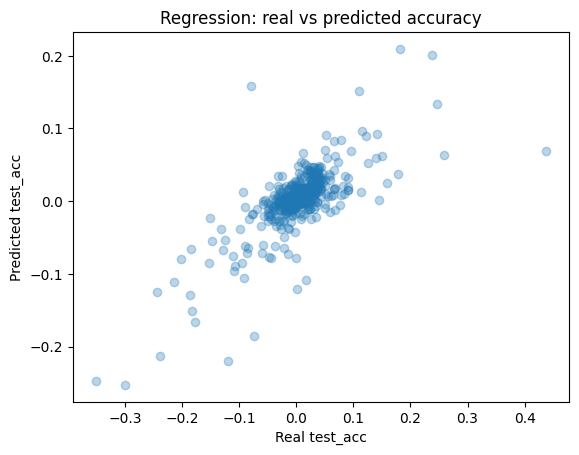

In [9]:
import matplotlib.pyplot as plt

pred = results.iloc[0]["mm"].predict(X_test)

plt.scatter(y_test, pred, alpha=0.3)

plt.xlabel("Real test_acc")
plt.ylabel("Predicted test_acc")
plt.title("Regression: real vs predicted accuracy")

# plt.plot([0,1],[0,1])
plt.show()


=== Результат предсказания следующего val_loss ===
MAE   = 0.01698
RMSE  = 0.03317
R²    = 0.5544   (55.44%)


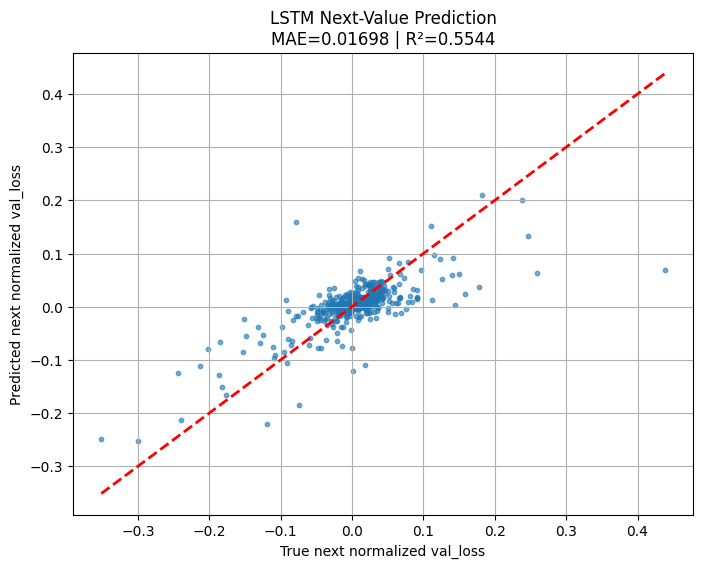

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Masking, LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ========================
# Создаём и обучаем модель
# ========================
# ========================
# Метрики
# ========================
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2  = r2_score(y_test, pred)

print("\n=== Результат предсказания следующего val_loss ===")
print(f"MAE   = {mae:.5f}")
print(f"RMSE  = {rmse:.5f}")
print(f"R²    = {r2:.4f}   ({r2*100:.2f}%)")

# ========================
# График True vs Predicted
# ========================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred, alpha=0.6, s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("True next normalized val_loss")
plt.ylabel("Predicted next normalized val_loss")
plt.title(f"LSTM Next-Value Prediction\nMAE={mae:.5f} | R²={r2:.4f}")
plt.grid(True)
plt.show()

In [11]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback

import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback

class SmartEarlyStoppingMultiStep(Callback):
    def __init__(self,
                 model_meta,
                 train_size,
                 future_steps=5,      # увеличил до 4
                 min_epochs=8,
                 patience=1,
                 restore_best_weights=True):   # ← Новый параметр
        super().__init__()
        self.model_meta = model_meta
        self.train_size = train_size
        self.future_steps = future_steps
        self.min_epochs = min_epochs
        self.patience = patience
        self.restore_best_weights = restore_best_weights

        self.val_loss = []
        self.best_val_loss = np.inf
        self.best_weights = None
        self.best_epoch = 0
        self.counter = 0

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get("val_loss")
        if val_loss is None:
            return

        self.val_loss.append(val_loss)

        # === Сохраняем лучшие веса ===
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.best_weights = self.model.get_weights()   # сохраняем веса
            self.best_epoch = epoch

        if len(self.val_loss) < self.min_epochs:
            return

        # Получаем прогноз
        preds = self.predict_future(epoch)

        current = self.val_loss[-1]
        future_min = min(preds)
        expected_improvement = current - future_min

        recent_std = np.std(self.val_loss[-8:]) if len(self.val_loss) >= 8 else 0.1

        # Более стабильное правило
        if expected_improvement < recent_std * 0.18:
            self.counter += 1
        else:
            self.counter = max(self.counter - 1, 0)

        print(f"epoch={epoch:3d} | val_loss={val_loss:.5f} | "
              f"future={[round(x,4) for x in preds]} | "
              f"improv={expected_improvement:.4f} | std={recent_std:.4f} | "
              f"counter={self.counter} | best={self.best_val_loss:.5f} (ep {self.best_epoch})")

        if self.counter >= self.patience:
            print(f"\n🔴 Expected future increase → stopping at epoch {epoch}")
            print(f"   Best val_loss = {self.best_val_loss:.5f} was at epoch {self.best_epoch}\n")

            # <<< ВОТ ГЛАВНОЕ ИСПРАВЛЕНИЕ >>>
            if self.restore_best_weights and self.best_weights is not None:
                print("→ Restoring best weights from epoch", self.best_epoch)
                self.model.set_weights(self.best_weights)

            self.model.stop_training = True

    def predict_future(self, epoch):
        val = list(self.val_loss)
        preds = []

        for step in range(self.future_steps):
            val_np = np.array(val)
            n = len(val_np)
            if n < 5:
                val_np = np.pad(val_np, (5 - n, 0), 'edge')

            x_full = np.arange(len(val_np))
            global_slope = np.polyfit(x_full, val_np, 1)[0] if len(val_np) > 1 else 0
            global_curvature = np.polyfit(x_full, val_np, 2)[0] if len(val_np) > 2 else 0
            best_idx = np.argmin(val_np)

            recent_window = 5
            val_recent = val_np[-recent_window:] if len(val_np) >= recent_window else val_np
            recent_slope = np.polyfit(np.arange(len(val_recent)), val_recent, 1)[0] if len(val_recent) > 1 else 0

            row = {
                "train_size": self.train_size,
                "epoch": epoch + step,
                "loss_start": val_np[0],
                "loss_mid": val_np[len(val_np)//2],
                "loss_last_1": val_np[-1] / val_np[0],
                "loss_last_2": val_np[-2] / val_np[0] if len(val_np) > 1 else 1.0,
                "global_slope": global_slope,
                "global_curvature": global_curvature,
                "epochs_since_best": len(val_np) - best_idx,
                "recent_slope": recent_slope,
                "recent_improvement": val_recent[0] - val_recent[-1] if len(val_recent) > 1 else 0,
                "acc_norm": (val_np[-1] - 2*val_np[-2] + val_np[-3]) / val_np[0] if len(val_np) > 2 else 0,
                "distance_norm": (val_np[-1] - min(val_np)) / (val_np[0] - min(val_np) + 1e-8),
            }

            df_row = pd.DataFrame([row])[feature_order]
            pred_delta = self.model_meta.predict(df_row)[0]
            next_val = val[-1] * (1 + pred_delta)
            preds.append(next_val)
            val.append(next_val)

        return preds

In [12]:
from tensorflow.keras.callbacks import Callback
import numpy as np
from scipy.optimize import curve_fit


class ParametricEarlyStopping(Callback):
    def __init__(self, min_epochs=8, patience=1, tol=1e-3):
        super().__init__()
        self.min_epochs = min_epochs
        self.patience = patience
        self.tol = tol

        self.val_loss = []
        self.counter = 0

    def exp_func(self, t, a, b, c):
        return a * np.exp(-b * t) + c

    def on_epoch_end(self, epoch, logs=None):
        val_loss = logs.get("val_loss")
        if val_loss is None:
            return

        self.val_loss.append(val_loss)

        if len(self.val_loss) < self.min_epochs:
            return

        y = np.array(self.val_loss)
        x = np.arange(len(y))

        try:
            # --- фит ---
            popt, _ = curve_fit(
                self.exp_func,
                x,
                y,
                bounds=(0, [10, 10, 10]),
                maxfev=5000
            )

            a, b, c = popt

            # --- прогноз ---
            future_epochs = np.arange(len(y), len(y) + 5)
            preds = self.exp_func(future_epochs, a, b, c)

            current = y[-1]
            future_min = preds.min()
            expected_improvement = current - future_min

            print(f"[Parametric] epoch={epoch} "
                  f"improv={expected_improvement:.6f} "
                  f"a={a:.3f} b={b:.3f} c={c:.3f}")

            if expected_improvement < self.tol:
                self.counter += 1
            else:
                self.counter = max(self.counter - 1, 0)

            if self.counter >= self.patience:
                print(f"🔵 Parametric stop at epoch {epoch}")
                self.model.stop_training = True

        except Exception:
            # если фит не сошёлся — игнорим
            pass

In [13]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)


def build_mlp_overfit():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),

        layers.Dense(32, activation="relu"),  # первый скрытый слой
        # layers.Dense(212, activation="relu"),     # второй скрытый слой
        # layers.Dense(256, activation="relu"),     # третий скрытый слой
        # Сильно уменьшаем Dropout или убираем его
        layers.Dropout(0.05),
        layers.Dense(10, activation="softmax")  # выходной слой
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
smart_stop = SmartEarlyStoppingMultiStep(
    model_reg,
    2000
)
model_mnist = build_mlp_overfit()
model_mnist.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_mnist.fit(
    X_train[:2000],
    y_train[:2000],

    validation_split=0.2,
    epochs=200,
    batch_size=10,
    # callbacks=[EarlyStopping(verbose=1, patience=5)]
    # callbacks=[smart_stop]

    callbacks=[smart_stop], verbose=0,
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=0.24442 | future=[np.float64(0.2421), np.float64(0.2409), np.float64(0.2399), np.float64(0.2393), np.float64(0.2386)] | improv=0.0058 | std=0.1362 | counter=1 | best=0.24442 (ep 7)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.24442 was at epoch 7

→ Restoring best weights from epoch 7


In [15]:
from tensorflow.keras.callbacks import EarlyStopping


def run_training(X, y, train_size, callback, X_test_df, y_test_df, build_model):
    curr_model = build_model()
    history = curr_model.fit(
        X[:train_size],
        y[:train_size],
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        verbose=0,
        callbacks=[callback]
    )

    epochs = len(history.history["loss"])

    # качество на тесте
    test_loss, test_acc = curr_model.evaluate(X_test_df, y_test_df, verbose=0)

    best_val_loss = min(history.history["val_loss"])

    return {
        "epochs": epochs,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "best_val_loss": best_val_loss
    }

In [16]:
def runner(sizes, X_train_df, y_train_Df, X_test_df, y_test_df, build_model):
    runs = 4

    results = []
    count = len(sizes) * runs
    for j, size in enumerate(sizes):

        for r in range(runs):
            print(j * runs + r, count, "*" * 20)
            early = EarlyStopping(
                monitor="val_loss",
                patience=5
            )
            parametric = ParametricEarlyStopping()
            smart = SmartEarlyStoppingMultiStep(
                model_reg,
                size
            )

            res_early = run_training(X_train_df, y_train_Df, size, early, X_test_df, y_test_df, build_model)
            res_smart = run_training(X_train_df, y_train_Df, size, smart, X_test_df, y_test_df, build_model)
            res_param = run_training(X_train_df, y_train_Df, size, parametric, X_test_df, y_test_df, build_model)
            results.append({
                "train_size": size,
                "run": r,

                "early_epochs": res_early["epochs"],
                "early_acc": res_early["test_acc"],
                "early_loss": res_early["test_loss"],

                "smart_epochs": res_smart["epochs"],
                "smart_acc": res_smart["test_acc"],
                "smart_loss": res_smart["test_loss"],
                "param_epochs": res_param["epochs"],
                "param_acc": res_param["test_acc"],
                "param_loss": res_param["test_loss"],
            })

    dfl = pd.DataFrame(results)
    dfl['diff_epochs'] = dfl['early_epochs'] - dfl['smart_epochs']
    dfl['diff_loss'] = dfl['early_loss'] - dfl['smart_loss']
    dfl['diff_acc'] = dfl['early_acc'] - dfl['smart_acc']
    return dfl


In [17]:
def sum_df(df_curr, sizes, k=-0.002):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    df_curr = df_curr.copy()

    # =========================
    # 🔹 FEATURE ENGINEERING
    # =========================

    df_curr["rel_epochs_saved"] = df_curr["diff_epochs"] / (df_curr["early_epochs"] + 1e-8)
    df_curr["acc_per_epoch"] = df_curr["diff_acc"] / (df_curr["diff_epochs"] + 1e-8)

    # Utility (ключевая метрика)
    df_curr["utility"] = df_curr["diff_acc"] + k * df_curr["diff_epochs"]

    # Победа Smart
    df_curr["smart_better"] = df_curr["utility"] > 0

    # Parametric diff
    df_curr["param_diff_epochs"] = df_curr["early_epochs"] - df_curr["param_epochs"]
    df_curr["param_diff_acc"] = df_curr["early_acc"] - df_curr["param_acc"]

    # =========================
    # 🔹 SUMMARY
    # =========================

    summary = df_curr.groupby("train_size").agg({
        "param_epochs": "mean",
        "param_acc": "mean",
        "param_loss": "mean",

        "early_acc": "mean",
        "smart_acc": "mean",

        "early_loss": "mean",
        "smart_loss": "mean",

        "early_epochs": "mean",
        "smart_epochs": "mean",

        "diff_epochs": "mean",
        "diff_acc": "mean",
        "diff_loss": "mean",

        "rel_epochs_saved": "mean",
        "utility": "mean",
        "smart_better": "mean"
    })

    print(summary)

    # =========================
    # 🔹 LOSS COMPARISON
    # =========================

    plt.figure(figsize=(8, 5))
    plt.plot(summary.index, summary["early_loss"], marker="o", label="EarlyStopping")
    plt.plot(summary.index, summary["smart_loss"], marker="o", label="SmartStop")
    plt.plot(summary.index, summary["param_loss"], marker="o", label="ParamStop")

    plt.xlabel("train_size")
    plt.ylabel("test_loss")
    plt.title("Callback quality comparison")
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # 🔹 EPOCHS BARPLOT
    # =========================

    summary[["early_epochs", "smart_epochs", "param_epochs"]].plot(
        kind="bar", figsize=(8, 5)
    )
    plt.ylabel("epochs trained")
    plt.title("Epochs until stopping")
    plt.grid()
    plt.show()

    # =========================
    # 🔹 TRADE-OFF (SMART)
    # =========================

    plt.figure(figsize=(8, 5))

    for size in sizes:
        subset = df_curr[df_curr["train_size"] == size]

        plt.scatter(
            subset["diff_epochs"],
            subset["diff_acc"],
            c=subset["utility"],
            cmap="coolwarm",
            s=80,
            alpha=0.8,
            label=f"{size}"
        )

    # Decision boundary
    x_vals = np.linspace(df_curr["diff_epochs"].min(), df_curr["diff_epochs"].max(), 100)
    y_vals = -k * x_vals
    plt.plot(x_vals, y_vals, linestyle="--", color="black", label=f"boundary k={k}")

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")

    plt.xlabel("epochs saved")
    plt.ylabel("accuracy diff (early - smart)")
    plt.title("Trade-off: speed vs accuracy (Smart)")
    plt.legend(title="train_size")
    plt.grid()
    plt.show()

    # =========================
    # 🔹 SMART vs PARAMETRIC
    # =========================

    plt.figure(figsize=(8, 5))

    plt.scatter(
        df_curr["param_diff_epochs"],
        df_curr["param_diff_acc"],
        alpha=0.6,
        label="Parametric"
    )

    plt.scatter(
        df_curr["diff_epochs"],
        df_curr["diff_acc"],
        alpha=0.6,
        label="Smart"
    )

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")

    plt.xlabel("epochs saved")
    plt.ylabel("accuracy diff")
    plt.title("Smart vs Parametric trade-off")
    plt.legend()
    plt.grid()
    plt.show()

    # =========================
    # 🔹 UTILITY DISTRIBUTION
    # =========================

    plt.figure(figsize=(8, 5))

    for size in sizes:
        subset = df_curr[df_curr["train_size"] == size]
        plt.scatter([size] * len(subset), subset["utility"])

    plt.axhline(0, linestyle="--")
    plt.xlabel("train_size")
    plt.ylabel("utility")
    plt.title("Utility vs dataset size")
    plt.grid()
    plt.show()

    # =========================
    # 🔹 WIN RATE
    # =========================

    plt.figure(figsize=(8, 5))

    plt.plot(summary.index, summary["smart_better"], marker="o")

    plt.xlabel("train_size")
    plt.ylabel("P(Smart better)")
    plt.title("Win rate of SmartEarlyStopping")
    plt.grid()
    plt.show()

    # =========================
    # 🔹 PARETO FRONTIER
    # =========================

    df_sorted = df_curr.sort_values("diff_epochs")

    pareto = []
    best_acc = -np.inf

    for _, row in df_sorted.iterrows():
        if row["diff_acc"] > best_acc:
            pareto.append(row)
            best_acc = row["diff_acc"]

    pareto = pd.DataFrame(pareto)

    plt.figure(figsize=(8, 5))

    plt.scatter(df_curr["diff_epochs"], df_curr["diff_acc"], alpha=0.4)
    plt.plot(pareto["diff_epochs"], pareto["diff_acc"], color="black", linewidth=2)

    plt.axhline(0, linestyle="--")
    plt.axvline(0, linestyle="--")

    plt.xlabel("epochs saved")
    plt.ylabel("accuracy diff")
    plt.title("Pareto frontier")
    plt.grid()
    plt.show()

    return summary, df_curr
sizes = [50, 500, 1000, 2000, 5000]

In [18]:
df = runner(sizes, X_train, y_train, X_test, y_test, build_mlp_overfit)

0 20 ********************


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=2.01579 | future=[np.float64(1.9731), np.float64(1.9375), np.float64(1.9017), np.float64(1.8596), np.float64(1.8199)] | improv=0.1959 | std=0.1031 | counter=0 | best=2.01579 (ep 7)
epoch=  8 | val_loss=1.98069 | future=[np.float64(1.9496), np.float64(1.9123), np.float64(1.8716), np.float64(1.8311), np.float64(1.7916)] | improv=0.1891 | std=0.1070 | counter=0 | best=1.98069 (ep 8)
epoch=  9 | val_loss=1.95416 | future=[np.float64(1.9185), np.float64(1.8774), np.float64(1.8383), np.float64(1.8014), np.float64(1.7672)] | improv=0.1870 | std=0.1079 | counter=0 | best=1.95416 (ep 9)
epoch= 10 | val_loss=1.93596 | future=[np.float64(1.904), np.float64(1.8728), np.float64(1.8402), np.float64(1.8104), np.float64(1.7772)] | improv=0.1587 | std=0.1019 | counter=0 | best=1.93596 (ep 10)
epoch= 11 | val_loss=1.91539 | future=[np.float64(1.8839), np.float64(1.8523), np.float64(1.8212), np.float64(1.7918), np.float64(1.7616)] | improv=0.1538 | std=0.0900 | counter=0 | best=1.915

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[Parametric] epoch=7 improv=0.219068 a=2.243 b=0.029 c=0.000
[Parametric] epoch=8 improv=0.225034 a=2.248 b=0.030 c=0.000
[Parametric] epoch=9 improv=0.229287 a=2.250 b=0.031 c=0.000
[Parametric] epoch=10 improv=0.227607 a=2.252 b=0.031 c=0.000
[Parametric] epoch=11 improv=0.230607 a=2.252 b=0.031 c=0.000
[Parametric] epoch=12 improv=0.233225 a=2.250 b=0.031 c=0.000
[Parametric] epoch=13 improv=0.238063 a=2.246 b=0.030 c=0.000
[Parametric] epoch=14 improv=0.214528 a=1.833 b=0.038 c=0.416
[Parametric] epoch=15 improv=0.187509 a=1.560 b=0.047 c=0.692
[Parametric] epoch=16 improv=0.163021 a=1.439 b=0.052 c=0.816
[Parametric] epoch=17 improv=0.146416 a=1.363 b=0.056 c=0.894
[Parametric] epoch=18 improv=0.133088 a=1.309 b=0.060 c=0.951
[Parametric] epoch=19 improv=0.121230 a=1.268 b=0.063 c=0.993
[Parametric] epoch=20 improv=0.109759 a=1.239 b=0.065 c=1.024
[Parametric] epoch=21 improv=0.104189 a=1.210 b=0.068 c=1.056
[Parametric] epoch=22 improv=0.098474 a=1.183 b=0.071 c=1.085
[Parametric

...

[Parametric] epoch=7 improv=-0.010034 a=0.196 b=0.582 c=0.274
🔵 Parametric stop at epoch 7
18 20 ********************
epoch=  7 | val_loss=0.28480 | future=[np.float64(0.2873), np.float64(0.2903), np.float64(0.2908), np.float64(0.2919), np.float64(0.2945)] | improv=-0.0025 | std=0.0647 | counter=1 | best=0.28351 (ep 6)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.28351 was at epoch 6

→ Restoring best weights from epoch 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[Parametric] epoch=7 improv=-0.012697 a=0.212 b=0.674 c=0.270
🔵 Parametric stop at epoch 7
19 20 ********************
epoch=  7 | val_loss=0.28626 | future=[np.float64(0.2868), np.float64(0.288), np.float64(0.2888), np.float64(0.2908), np.float64(0.2908)] | improv=-0.0006 | std=0.0640 | counter=1 | best=0.28008 (ep 6)

🔴 Expected future increase → stopping at epoch 7
   Best val_loss = 0.28008 was at epoch 6

→ Restoring best weights from epoch 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[Parametric] epoch=7 improv=0.006324 a=0.198 b=0.619 c=0.275
[Parametric] epoch=8 improv=-0.002392 a=0.199 b=0.603 c=0.273
🔵 Parametric stop at epoch 8


            param_epochs  param_acc  param_loss  early_acc  smart_acc  \
train_size                                                              
50                104.00   0.592125    1.524781   0.567950    0.56810   
500                11.00   0.810650    0.627849   0.818525    0.80460   
1000                8.25   0.860550    0.465613   0.871075    0.86050   
2000                8.00   0.887775    0.383940   0.891600    0.88555   
5000                8.25   0.918250    0.271776   0.922975    0.91545   

            early_loss  smart_loss  early_epochs  smart_epochs  diff_epochs  \
train_size                                                                    
50            1.584768    1.516838         52.50          46.5         6.00   
500           0.603726    0.657187         20.75           8.0        12.75   
1000          0.430117    0.463722         18.25           8.0        10.25   
2000          0.397281    0.384090         23.25           8.0        15.25   
5000          

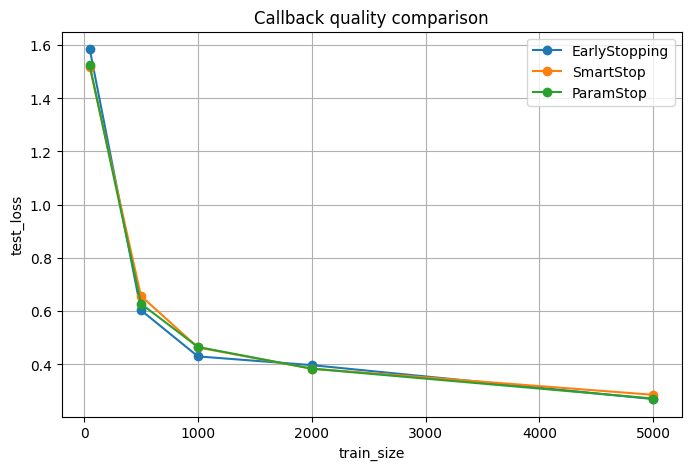

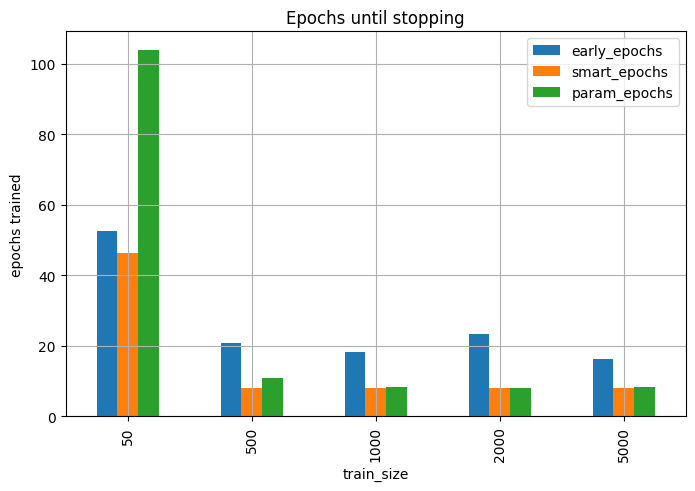

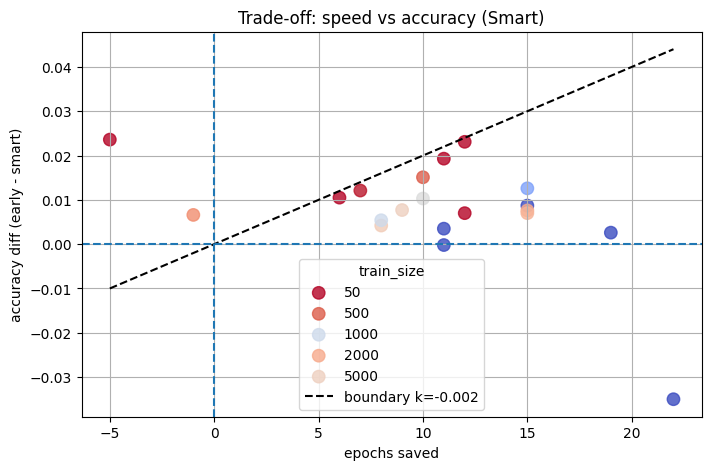

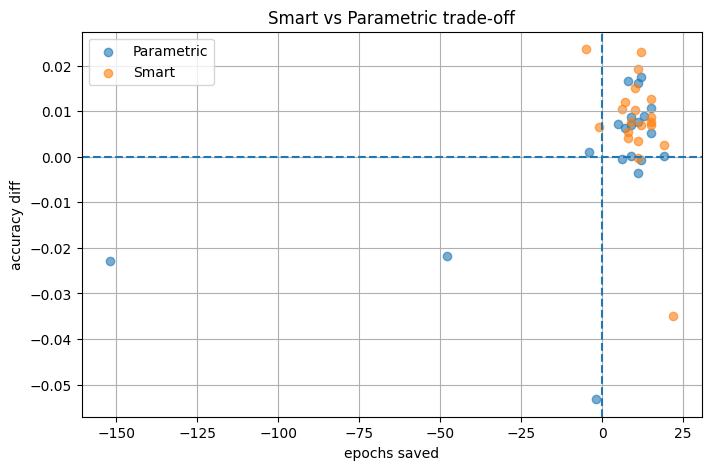

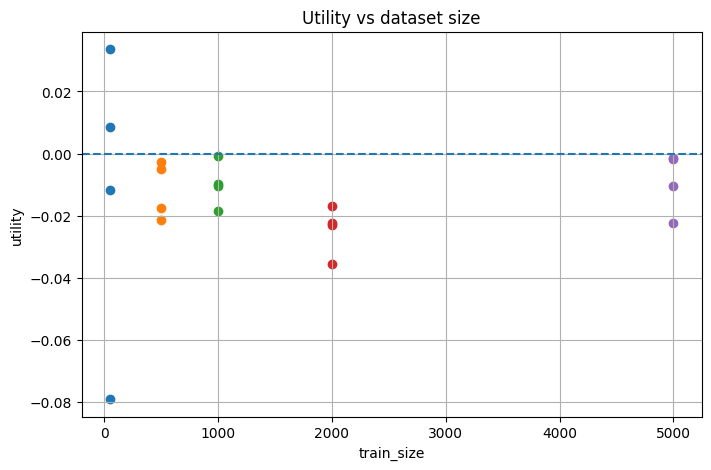

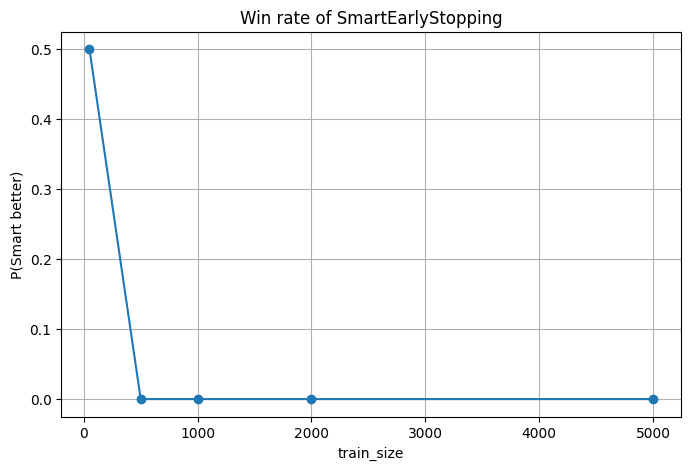

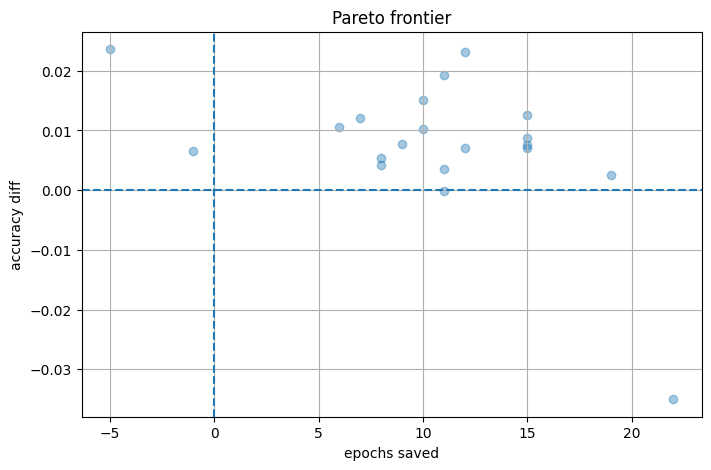

    train_size  run  early_epochs  early_acc  early_loss  smart_epochs  \
0           50    0            49     0.5771    1.587950            54   
1           50    1            48     0.5741    1.589787            40   
2           50    2            53     0.5662    1.523470            54   
3           50    3            60     0.5544    1.637865            38   
4          500    0            18     0.8167    0.588739             8   
5          500    1            23     0.8221    0.616242             8   
6          500    2            23     0.8140    0.639127             8   
7          500    3            19     0.8213    0.570798             8   
8         1000    0            16     0.8722    0.427567             8   
9         1000    1            18     0.8653    0.437585             8   
10        1000    2            19     0.8692    0.438704             8   
11        1000    3            20     0.8776    0.416613             8   
12        2000    0            23     

In [19]:
sum_df(df, sizes)
print(df.head(100))

In [20]:
from pandas import read_csv, get_dummies
from sklearn.model_selection import train_test_split

df_student_med = read_csv('data/WineQT.csv')

X, Y = df_student_med[
    'fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol'.split(
        ',')
], df_student_med['quality']
X = get_dummies(X, drop_first=True)
from sklearn.preprocessing import Normalizer

normalizer = Normalizer()
X = normalizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


# print(y_test[:90])
def build_model_med():
    model = models.Sequential([
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


df_med = runner(sizes, X_train, y_train, X_test, y_test, build_model_med)

0 20 ********************
epoch=  7 | val_loss=1.93875 | future=[np.float64(1.9053), np.float64(1.8783), np.float64(1.8486), np.float64(1.8173), np.float64(1.7868)] | improv=0.1519 | std=0.1329 | counter=0 | best=1.93875 (ep 7)
epoch=  8 | val_loss=1.88539 | future=[np.float64(1.8519), np.float64(1.826), np.float64(1.7969), np.float64(1.7653), np.float64(1.7355)] | improv=0.1499 | std=0.1292 | counter=0 | best=1.88539 (ep 8)
epoch=  9 | val_loss=1.83340 | future=[np.float64(1.8018), np.float64(1.7765), np.float64(1.7478), np.float64(1.7172), np.float64(1.6895)] | improv=0.1439 | std=0.1263 | counter=0 | best=1.83340 (ep 9)
epoch= 10 | val_loss=1.78021 | future=[np.float64(1.7505), np.float64(1.7257), np.float64(1.6982), np.float64(1.6696), np.float64(1.6414)] | improv=0.1388 | std=0.1241 | counter=0 | best=1.78021 (ep 10)
epoch= 11 | val_loss=1.72776 | future=[np.float64(1.6979), np.float64(1.6742), np.float64(1.6478), np.float64(1.6209), np.float64(1.5946)] | improv=0.1332 | std=0.122

In [26]:
# sum_df(df_med, sizes)
# print(df_med.head(100))
print(df_med.head())


   train_size  run  early_epochs  early_acc  early_loss  smart_epochs  \
0          50    0            40   0.436681    1.154304            48   
1          50    1            50   0.423581    1.156951            45   
2          50    2            43   0.436681    1.159760            50   
3          50    3            51   0.441048    1.151889            41   
4         500    0            28   0.545852    1.077426             8   

   smart_acc  smart_loss  param_epochs  param_acc  param_loss  diff_epochs  \
0   0.458515    1.143937            82   0.467249    1.138390           -8   
1   0.454148    1.148439           102   0.471616    1.149935            5   
2   0.436681    1.150185           106   0.467249    1.155586           -7   
3   0.436681    1.153597           126   0.484716    1.141270           10   
4   0.519651    1.118260             8   0.502183    1.121909           20   

   diff_loss  diff_acc  
0   0.010368 -0.021834  
1   0.008512 -0.030568  
2   0.009575  0.0

In [22]:
import numpy as np
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# ====================== ЗАГРУЗКА CIFAR-10 ======================
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# Нормализация данных (приведение к диапазону [0, 1])
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Преобразование меток в одномерный массив (для sparse_categorical_crossentropy)
y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

print(f"Полный размер обучающей выборки: {X_train_full.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# ====================== ФУНКЦИЯ СОЗДАНИЯ МОДЕЛИ ======================
def build_model_cifar():
    model = models.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),

        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.1),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# ====================== ЗАПУСК ЭКСПЕРИМЕНТА ======================
# Размеры обучающей выборки, которые будем тестировать

# Запуск сравнения EarlyStopping vs SmartEarlyStopping
df_cifar = runner(sizes, X_train_full, y_train_full, X_test, y_test, build_model_cifar)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Полный размер обучающей выборки: 50000
Размер тестовой выборки: 10000
0 20 ********************


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


epoch=  7 | val_loss=2.72176 | future=[np.float64(2.5976), np.float64(2.5807), np.float64(2.5321), np.float64(2.4063), np.float64(2.3199)] | improv=0.4018 | std=0.2912 | counter=0 | best=2.55296 (ep 2)
epoch=  8 | val_loss=2.99055 | future=[np.float64(2.6574), np.float64(2.5306), np.float64(2.4288), np.float64(2.3601), np.float64(2.1977)] | improv=0.7928 | std=0.2226 | counter=0 | best=2.55296 (ep 2)
epoch=  9 | val_loss=3.05919 | future=[np.float64(2.7776), np.float64(2.6292), np.float64(2.612), np.float64(2.6068), np.float64(2.5932)] | improv=0.4660 | std=0.2214 | counter=0 | best=2.55296 (ep 2)
epoch= 10 | val_loss=3.13276 | future=[np.float64(3.1318), np.float64(3.2764), np.float64(3.4998), np.float64(3.7553), np.float64(4.0452)] | improv=0.0010 | std=0.1570 | counter=1 | best=2.55296 (ep 2)

🔴 Expected future increase → stopping at epoch 10
   Best val_loss = 2.55296 was at epoch 2

→ Restoring best weights from epoch 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[Parametric] epoch=7 improv=-0.062762 a=1.124 b=10.000 c=2.909
🔵 Parametric stop at epoch 7
1 20 ********************
epoch=  7 | val_loss=2.50323 | future=[np.float64(2.4681), np.float64(2.3673), np.float64(2.2971), np.float64(2.2027), np.float64(2.1694)] | improv=0.3338 | std=0.7022 | counter=0 | best=2.47672 (ep 5)
epoch=  8 | val_loss=2.60749 | future=[np.float64(2.5451), np.float64(2.6939), np.float64(2.5663), np.float64(2.6343), np.float64(2.592)] | improv=0.0624 | std=0.2251 | counter=0 | best=2.47672 (ep 5)
epoch=  9 | val_loss=3.43737 | future=[np.float64(3.386), np.float64(3.436), np.float64(3.712), np.float64(4.0522), np.float64(4.3625)] | improv=0.0513 | std=0.3093 | counter=1 | best=2.47672 (ep 5)

🔴 Expected future increase → stopping at epoch 9
   Best val_loss = 2.47672 was at epoch 5

→ Restoring best weights from epoch 5


...

[Parametric] epoch=7 improv=0.040130 a=0.294 b=0.163 c=1.783
[Parametric] epoch=8 improv=0.044429 a=0.293 b=0.163 c=1.784
[Parametric] epoch=9 improv=0.037736 a=0.270 b=0.189 c=1.809
[Parametric] epoch=10 improv=0.042654 a=0.233 b=0.256 c=1.850
[Parametric] epoch=11 improv=0.029660 a=0.220 b=0.294 c=1.864
[Parametric] epoch=12 improv=-0.016333 a=0.230 b=0.261 c=1.853
🔵 Parametric stop at epoch 12
18 20 ********************
epoch=  7 | val_loss=1.85669 | future=[np.float64(1.8294), np.float64(1.7959), np.float64(1.7692), np.float64(1.7473), np.float64(1.7252)] | improv=0.1315 | std=0.0643 | counter=0 | best=1.85669 (ep 7)
epoch=  8 | val_loss=1.90826 | future=[np.float64(1.7904), np.float64(1.7378), np.float64(1.7152), np.float64(1.6901), np.float64(1.6567)] | improv=0.2515 | std=0.0431 | counter=0 | best=1.85669 (ep 7)
epoch=  9 | val_loss=1.87311 | future=[np.float64(1.8552), np.float64(1.8333), np.float64(1.8085), np.float64(1.7773), np.float64(1.7501)] | improv=0.1230 | std=0.0378 |

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[Parametric] epoch=7 improv=0.074034 a=0.181 b=0.403 c=1.910
[Parametric] epoch=8 improv=-0.002422 a=0.190 b=0.361 c=1.900
🔵 Parametric stop at epoch 8
19 20 ********************
epoch=  7 | val_loss=1.94173 | future=[np.float64(1.8117), np.float64(1.7454), np.float64(1.7143), np.float64(1.6851), np.float64(1.6477)] | improv=0.2940 | std=0.0775 | counter=0 | best=1.90934 (ep 6)
epoch=  8 | val_loss=1.97182 | future=[np.float64(1.798), np.float64(1.7432), np.float64(1.7159), np.float64(1.6861), np.float64(1.6522)] | improv=0.3196 | std=0.0691 | counter=0 | best=1.90934 (ep 6)
epoch=  9 | val_loss=1.91215 | future=[np.float64(1.8644), np.float64(1.8388), np.float64(1.8143), np.float64(1.7802), np.float64(1.7506)] | improv=0.1615 | std=0.0633 | counter=0 | best=1.90934 (ep 6)
epoch= 10 | val_loss=1.91566 | future=[np.float64(1.9474), np.float64(1.9099), np.float64(1.9374), np.float64(1.9761), np.float64(1.9864)] | improv=0.0057 | std=0.0643 | counter=1 | best=1.90934 (ep 6)

🔴 Expected fu

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[Parametric] epoch=7 improv=0.054479 a=0.308 b=0.178 c=1.787
[Parametric] epoch=8 improv=0.051589 a=0.354 b=0.142 c=1.738
[Parametric] epoch=9 improv=0.047270 a=0.319 b=0.169 c=1.776
[Parametric] epoch=10 improv=0.040396 a=0.284 b=0.214 c=1.815
[Parametric] epoch=11 improv=0.023980 a=0.275 b=0.231 c=1.825
[Parametric] epoch=12 improv=0.004475 a=0.282 b=0.217 c=1.817
[Parametric] epoch=13 improv=0.017829 a=0.277 b=0.227 c=1.822
[Parametric] epoch=14 improv=0.026153 a=0.270 b=0.246 c=1.832
[Parametric] epoch=15 improv=0.034607 a=0.262 b=0.271 c=1.842
[Parametric] epoch=16 improv=0.034501 a=0.257 b=0.293 c=1.849
[Parametric] epoch=17 improv=-0.013293 a=0.259 b=0.284 c=1.847
🔵 Parametric stop at epoch 17


    train_size  run  early_epochs  early_acc  early_loss  smart_epochs  \
0           50    0             7     0.1203    2.551101            11   
1           50    1            17     0.1684    2.832069            10   
2           50    2             7     0.1550    2.591402             9   
3           50    3             9     0.1402    2.726940             8   
4          500    0            25     0.2865    2.040620            15   
5          500    1            24     0.2636    2.062452            11   
6          500    2            21     0.2472    2.079279             8   
7          500    3             7     0.2220    2.068831             9   
8         1000    0            15     0.2689    1.982793            18   
9         1000    1            28     0.2969    1.969244            10   
10        1000    2            25     0.2921    1.977372            14   
11        1000    3            34     0.2979    2.047199             9   
12        2000    0            48     

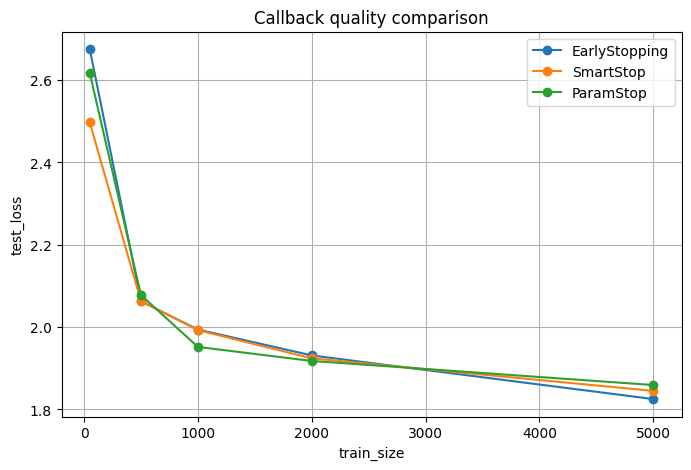

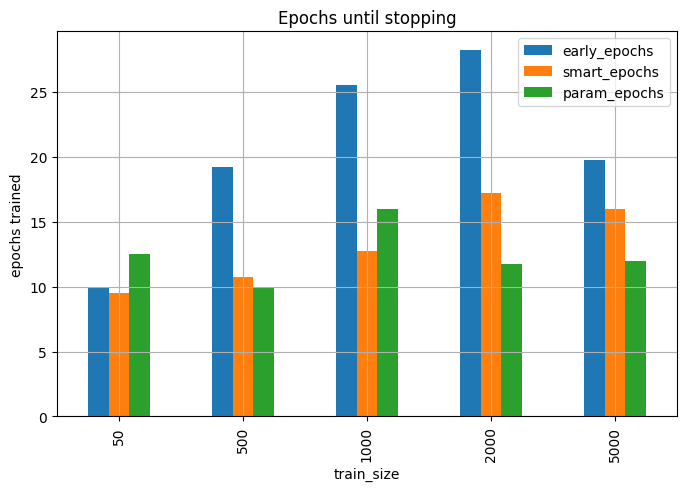

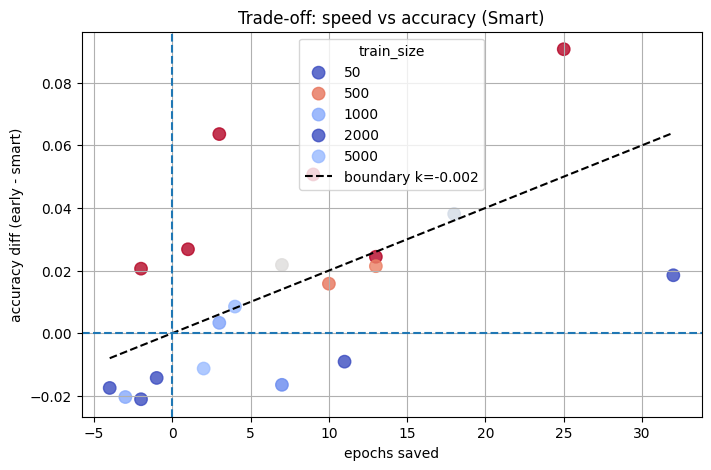

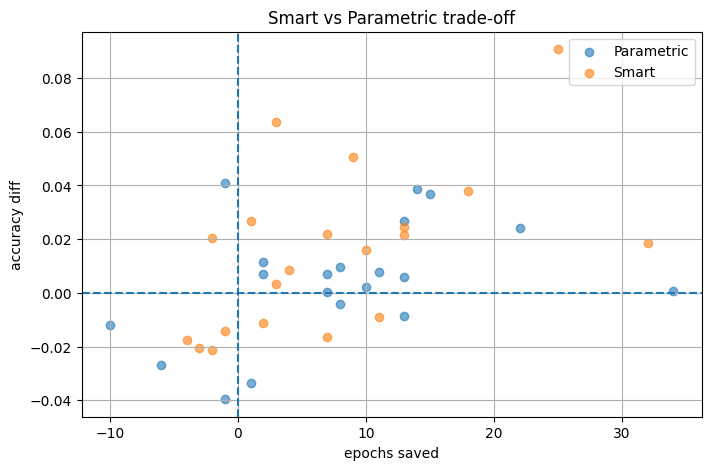

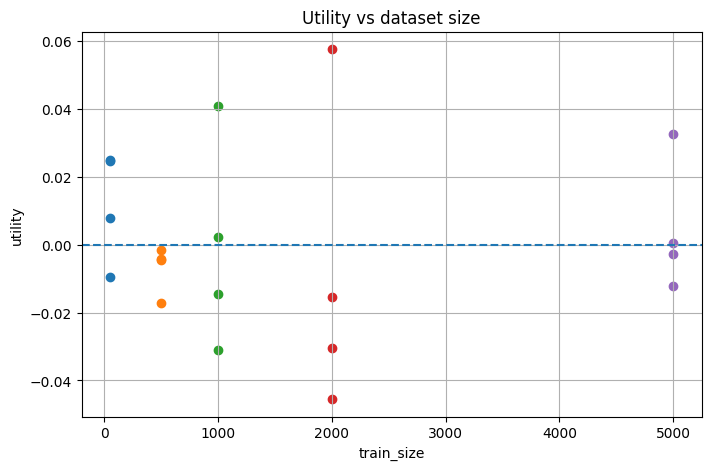

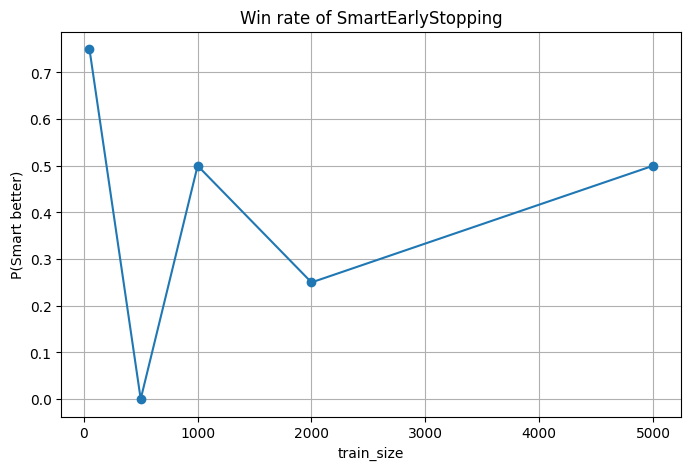

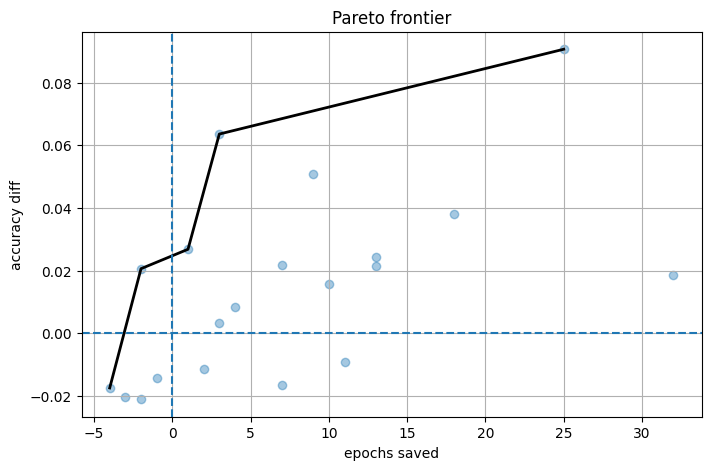

(            param_epochs  param_acc  param_loss  early_acc  smart_acc  \
 train_size                                                              
 50                 12.50   0.165475    2.617673   0.145975   0.133050   
 500                10.00   0.228200    2.077872   0.254825   0.244700   
 1000               16.00   0.288025    1.951951   0.288950   0.264125   
 2000               11.75   0.297675    1.917862   0.300000   0.286425   
 5000               12.00   0.320600    1.859380   0.333975   0.321925   
 
             early_loss  smart_loss  early_epochs  smart_epochs  diff_epochs  \
 train_size                                                                    
 50            2.675378    2.497506         10.00          9.50         0.50   
 500           2.062796    2.063044         19.25         10.75         8.50   
 1000          1.994152    1.992692         25.50         12.75        12.75   
 2000          1.931289    1.924283         28.25         17.25        11.00   


In [23]:
print(df_cifar.head(100))
sum_df(df_cifar, sizes)


            param_epochs  param_acc  param_loss  early_acc  smart_acc  \
train_size                                                              
50.0              58.250   0.378800    2.071227   0.356963   0.350575   
500.0             10.500   0.519425    1.352861   0.536675   0.524650   
1000.0            12.125   0.574288    1.208782   0.580013   0.562313   
2000.0             9.875   0.592725    1.150901   0.595800   0.585987   
5000.0            10.125   0.619425    1.065578   0.628475   0.618688   

            early_loss  smart_loss  early_epochs  smart_epochs  diff_epochs  \
train_size                                                                    
50.0          2.130073    2.007172        31.250        28.000        3.250   
500.0         1.333261    1.360115        20.000         9.375       10.625   
1000.0        1.212135    1.228207        21.875        10.375       11.500   
2000.0        1.164285    1.154186        25.750        12.625       13.125   
5000.0        

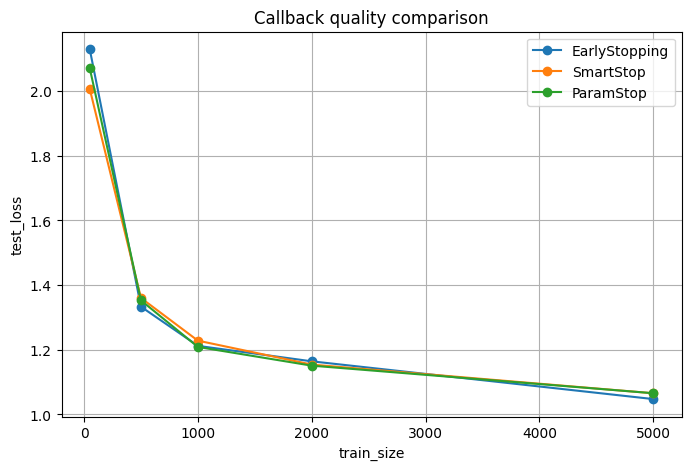

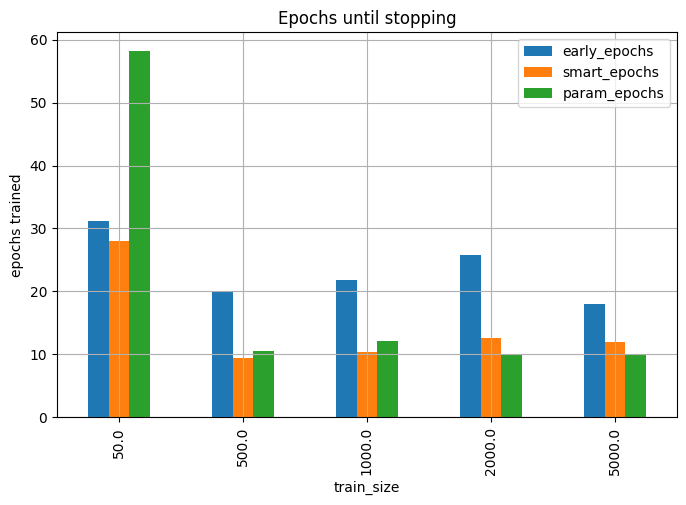

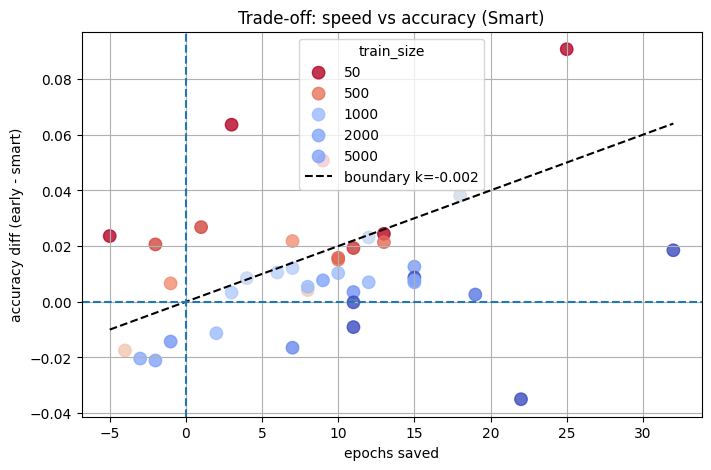

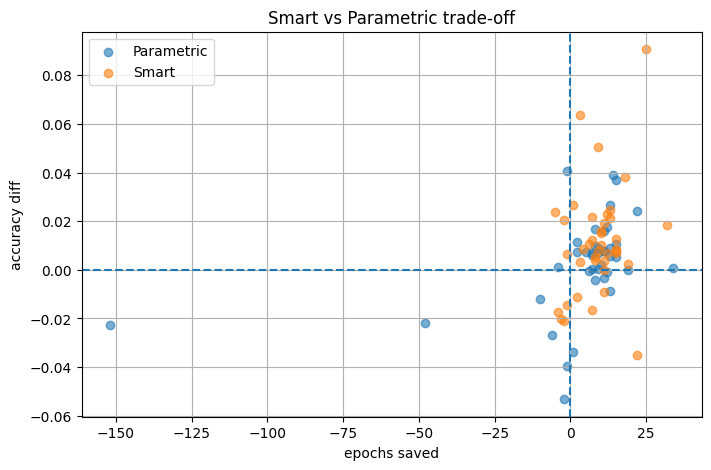

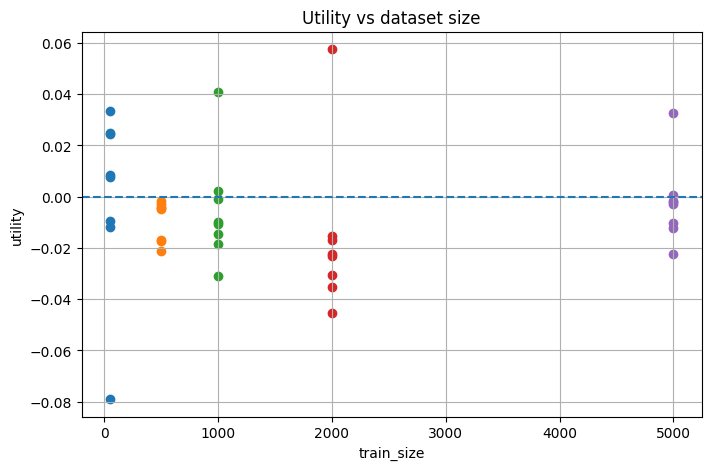

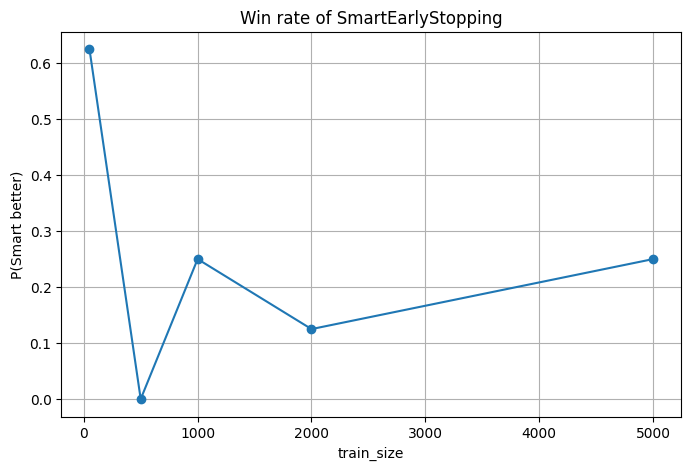

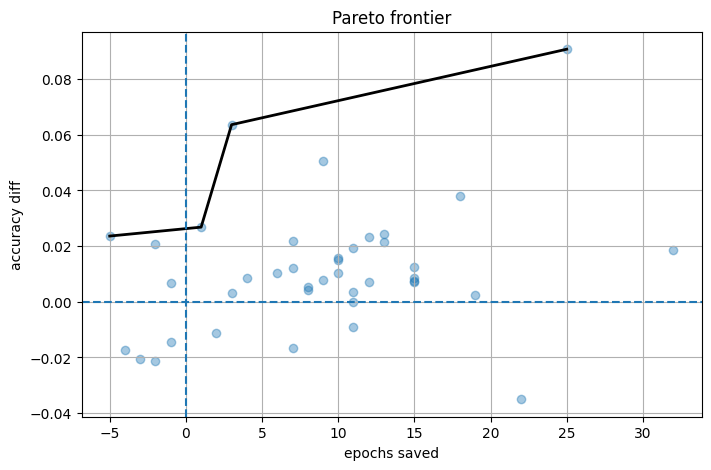

(            param_epochs  param_acc  param_loss  early_acc  smart_acc  \
 train_size                                                              
 50.0              58.250   0.378800    2.071227   0.356963   0.350575   
 500.0             10.500   0.519425    1.352861   0.536675   0.524650   
 1000.0            12.125   0.574288    1.208782   0.580013   0.562313   
 2000.0             9.875   0.592725    1.150901   0.595800   0.585987   
 5000.0            10.125   0.619425    1.065578   0.628475   0.618688   
 
             early_loss  smart_loss  early_epochs  smart_epochs  diff_epochs  \
 train_size                                                                    
 50.0          2.130073    2.007172        31.250        28.000        3.250   
 500.0         1.333261    1.360115        20.000         9.375       10.625   
 1000.0        1.212135    1.228207        21.875        10.375       11.500   
 2000.0        1.164285    1.154186        25.750        12.625       13.125   


In [29]:
df["dataset"] = "mnist"
df_cifar["dataset"] = "cifar"
df_student_med["dataset"] = "wine"
df_all = pd.concat([df, df_cifar, df_student_med], ignore_index=True)
sum_df(df_all, sizes)